# HCD-202 Ethical Principles for AI
## Fairness Experiment: Student Performance Prediction

**Author:** Bawornpat Rattanapongkiat (Pepper)  
**Course:** HCD-202 — Ethical Principles for AI  
**Date:** 5 May 2026  
**Dataset:** [Kaggle – Student Performance Predictions](https://www.kaggle.com/datasets/haseebindata/student-performance-predictions)

---

### Research Hypothesis
> The model may exhibit unfairness by predicting different academic outcomes for students based on **gender**, even when all other variables (study hours, attendance, previous grades, parental support) are the same.

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import warnings, os

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load & Explore the Dataset

The dataset contains 1,000 student records with features such as study hours, attendance, previous grades, parental support, and gender. We first check for missing values and understand the distribution of key columns.

In [2]:
df = pd.read_csv('student_performance_updated_1000.csv')
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (1000, 12)
Columns: ['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [3]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64


In [4]:
print('Gender distribution:')
print(df['Gender'].value_counts())
print()
print('Parental Support distribution:')
print(df['ParentalSupport'].value_counts())
print()
print('FinalGrade statistics:')
print(df['FinalGrade'].describe())

Gender distribution:
Gender
Male      501
Female    451
Name: count, dtype: int64

Parental Support distribution:
ParentalSupport
High      345
Medium    328
Low       305
Name: count, dtype: int64

FinalGrade statistics:
count    960.000000
mean      80.030208
std        9.493652
min       62.000000
25%       72.000000
50%       80.000000
75%       88.000000
max       92.000000
Name: FinalGrade, dtype: float64


## 3. Data Cleaning

We select the relevant features and drop rows with missing values.  
Since all FinalGrade values are above 62 in this dataset, a **median split** is used to create a binary target:
- **High Performer (1):** FinalGrade >= 80 (median)
- **Low Performer (0):** FinalGrade < 80

In [5]:
FEATURES = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
            'ExtracurricularActivities', 'ParentalSupport', 'Gender']
TARGET_COL = 'FinalGrade'

df_clean = df[FEATURES + [TARGET_COL]].dropna()
print('Dataset after dropping missing values:', df_clean.shape)

# Encode ParentalSupport: Low=0, Medium=1, High=2
support_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_clean = df_clean[df_clean['ParentalSupport'].isin(support_map)].copy()
df_clean['ParentalSupport_enc'] = df_clean['ParentalSupport'].map(support_map)

# Encode Gender: Male=0, Female=1
df_clean = df_clean[df_clean['Gender'].isin(['Male', 'Female'])].copy()
df_clean['Gender_enc'] = (df_clean['Gender'] == 'Female').astype(int)

# Binary target using median split
PASS_THRESHOLD = df_clean['FinalGrade'].median()
df_clean['Pass'] = (df_clean['FinalGrade'] >= PASS_THRESHOLD).astype(int)

print('Pass threshold (median FinalGrade):', PASS_THRESHOLD)
print('Class balance:')
print(df_clean['Pass'].value_counts())
print('Gender balance:')
print(df_clean['Gender'].value_counts())

df_clean.to_csv('outputs/cleaned_dataset.csv', index=False)
print('Saved: outputs/cleaned_dataset.csv')

Dataset after dropping missing values: (761, 7)
Pass threshold (median FinalGrade): 80.0
Class balance:
Pass
1    447
0    314
Name: count, dtype: int64
Gender balance:
Gender
Male      409
Female    352
Name: count, dtype: int64
Saved: outputs/cleaned_dataset.csv


## 4. Exploratory Data Analysis

Before training, we visualize key features split by gender to understand the raw data.

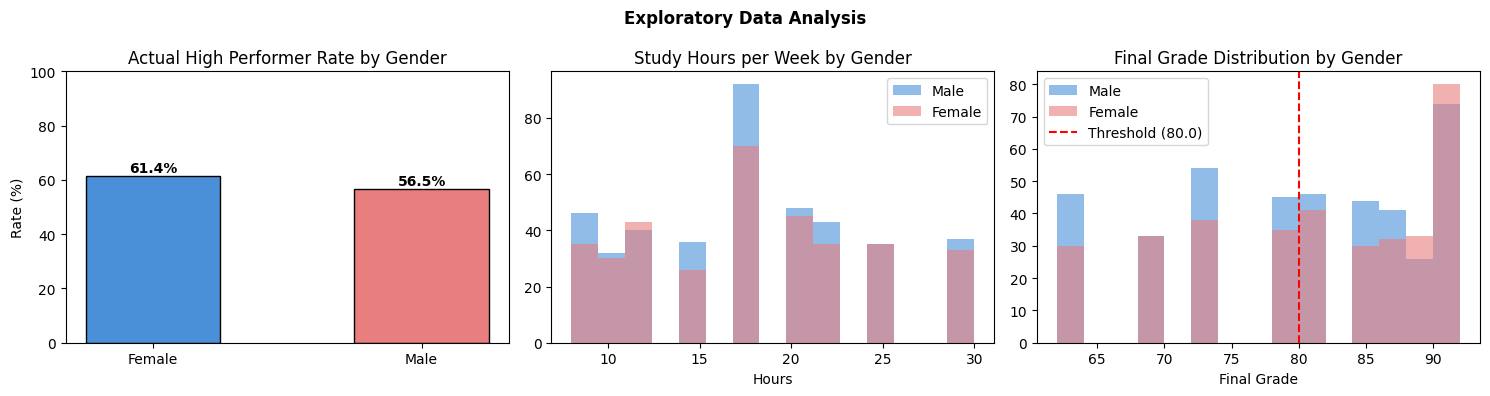

Saved: outputs/eda_charts.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual high-performer rate by gender
pass_by_gender = df_clean.groupby('Gender')['Pass'].mean() * 100
axes[0].bar(pass_by_gender.index, pass_by_gender.values,
            color=['#4A90D9', '#E87E7E'], edgecolor='black', width=0.5)
axes[0].set_title('Actual High Performer Rate by Gender')
axes[0].set_ylabel('Rate (%)')
axes[0].set_ylim(0, 100)
for i, (label, val) in enumerate(pass_by_gender.items()):
    axes[0].text(i, val + 1.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Study hours distribution
for gender, color in [('Male', '#4A90D9'), ('Female', '#E87E7E')]:
    axes[1].hist(df_clean[df_clean['Gender'] == gender]['StudyHoursPerWeek'],
                 alpha=0.6, label=gender, color=color, bins=15)
axes[1].set_title('Study Hours per Week by Gender')
axes[1].set_xlabel('Hours')
axes[1].legend()

# Final grade distribution
for gender, color in [('Male', '#4A90D9'), ('Female', '#E87E7E')]:
    axes[2].hist(df_clean[df_clean['Gender'] == gender]['FinalGrade'],
                 alpha=0.6, label=gender, color=color, bins=15)
axes[2].axvline(PASS_THRESHOLD, color='red', linestyle='--',
                label=f'Threshold ({PASS_THRESHOLD})')
axes[2].set_title('Final Grade Distribution by Gender')
axes[2].set_xlabel('Final Grade')
axes[2].legend()

plt.suptitle('Exploratory Data Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_charts.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/eda_charts.png')

## 5. Train the Logistic Regression Model

The model is trained on 80% of the data. Gender is included as a feature to reflect a realistic deployment scenario — this also lets us measure its influence via coefficients.

In [7]:
FEATURE_COLS = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
                'ExtracurricularActivities', 'ParentalSupport_enc', 'Gender_enc']

X = df_clean[FEATURE_COLS].values
y = df_clean['Pass'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_sc, y_train)

print('Model trained successfully.')
print(f'Training size: {len(X_train)} | Test size: {len(X_test)}')

Model trained successfully.
Training size: 608 | Test size: 153


In [8]:
y_pred = model.predict(X_test_sc)
print('Classification Report (Test Set):')
print(classification_report(y_test, y_pred,
      target_names=['Low Performer', 'High Performer']))

Classification Report (Test Set):
                precision    recall  f1-score   support

 Low Performer       0.00      0.00      0.00        63
High Performer       0.59      1.00      0.74        90

      accuracy                           0.59       153
     macro avg       0.29      0.50      0.37       153
  weighted avg       0.35      0.59      0.44       153



## 6. Model Coefficients

The Logistic Regression coefficients show how much each feature influences the prediction.  
A larger absolute value = stronger influence on the outcome.

In [9]:
coef_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature Coefficients (sorted by absolute influence):')
print(coef_df.to_string(index=False))
coef_df.to_csv('outputs/model_coefficients.csv', index=False)
print('Saved: outputs/model_coefficients.csv')

Feature Coefficients (sorted by absolute influence):
                  Feature  Coefficient
               Gender_enc     0.096933
            PreviousGrade     0.071410
      ParentalSupport_enc    -0.044175
        StudyHoursPerWeek     0.037208
           AttendanceRate     0.024681
ExtracurricularActivities    -0.018593
Saved: outputs/model_coefficients.csv


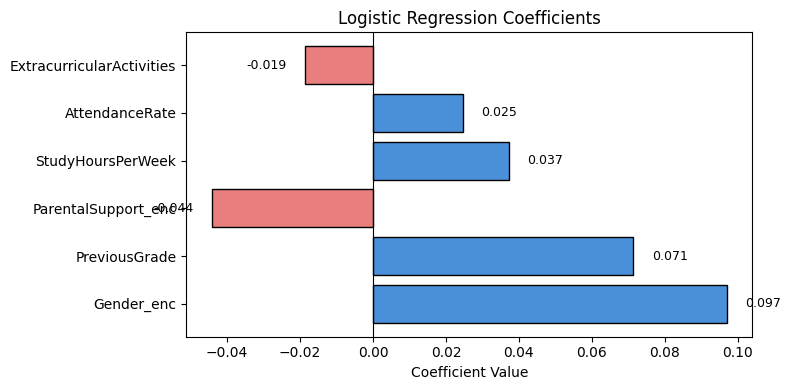

Saved: outputs/coefficients_chart.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E87E7E' if c < 0 else '#4A90D9' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
               color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients')
ax.set_xlabel('Coefficient Value')
for bar, val in zip(bars, coef_df['Coefficient']):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/coefficients_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/coefficients_chart.png')

## 7. Fairness Experiment — Counterfactual Gender Test

**Method:** For each of 200 unique student profiles, we create **two identical copies** — one labeled Male, one labeled Female — and compare the model's predicted probability.  

This isolates the effect of gender: any change in probability is caused purely by gender, not by any academic difference.

In [11]:
# Select 200 unique base profiles
base_profiles = df_clean[['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
                           'ExtracurricularActivities', 'ParentalSupport_enc']]\
                    .drop_duplicates().reset_index(drop=True)

np.random.seed(42)
if len(base_profiles) > 200:
    base_profiles = base_profiles.sample(200, random_state=42).reset_index(drop=True)

print(f'Unique base profiles: {len(base_profiles)}')

# Create counterfactual pairs
records = []
for idx, row in base_profiles.iterrows():
    for gender_label, gender_enc in [('Male', 0), ('Female', 1)]:
        r = row.to_dict()
        r['Gender']     = gender_label
        r['Gender_enc'] = gender_enc
        r['ProfileID']  = idx
        records.append(r)

cf_df = pd.DataFrame(records)
print(f'Total test records (200 profiles x 2 genders): {len(cf_df)}')
cf_df.head(4)

Unique base profiles: 200
Total test records (200 profiles x 2 genders): 400


,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport_enc,Gender,Gender_enc,ProfileID
0,90.0,17.0,65.0,3.0,0.0,Male,0,0
1,90.0,17.0,65.0,3.0,0.0,Female,1,0
2,78.0,25.0,85.0,3.0,0.0,Male,0,1
3,78.0,25.0,85.0,3.0,0.0,Female,1,1


In [12]:
# Run predictions on counterfactual data
cf_X    = cf_df[FEATURE_COLS].values
cf_X_sc = scaler.transform(cf_X)

cf_df['PredPass'] = model.predict(cf_X_sc)
cf_df['ProbPass'] = model.predict_proba(cf_X_sc)[:, 1]

cf_df.to_csv('outputs/counterfactual_test_data.csv', index=False)
print('Saved: outputs/counterfactual_test_data.csv')
cf_df[['ProfileID', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'PredPass', 'ProbPass']].head(6)

Saved: outputs/counterfactual_test_data.csv


,ProfileID,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,PredPass,ProbPass
0,0,Male,90.0,17.0,65.0,1,0.553925
1,0,Female,90.0,17.0,65.0,1,0.601430
2,1,Male,78.0,25.0,85.0,1,0.590246
3,1,Female,78.0,25.0,85.0,1,0.636421
4,2,Male,70.0,22.0,88.0,1,0.562602
5,2,Female,70.0,22.0,88.0,1,0.609834


## 8. Results & Analysis

In [13]:
male_cf   = cf_df[cf_df['Gender'] == 'Male']
female_cf = cf_df[cf_df['Gender'] == 'Female']

male_pass_rate   = male_cf['PredPass'].mean()   * 100
female_pass_rate = female_cf['PredPass'].mean() * 100
male_prob_mean   = male_cf['ProbPass'].mean()
female_prob_mean = female_cf['ProbPass'].mean()

print('--- Predicted High-Performer Rates (Counterfactual) ---')
print(f'Male   predicted pass rate : {male_pass_rate:.2f}%')
print(f'Female predicted pass rate : {female_pass_rate:.2f}%')
print(f'Difference (Male - Female) : {male_pass_rate - female_pass_rate:.2f}%')
print()
print('--- Mean Predicted Probability ---')
print(f'Male   mean prob  : {male_prob_mean:.4f}')
print(f'Female mean prob  : {female_prob_mean:.4f}')
print(f'Difference        : {male_prob_mean - female_prob_mean:.4f}')

# Profile-level differences
pivot = cf_df.pivot(index='ProfileID', columns='Gender', values='ProbPass')
pivot['Diff'] = pivot['Male'] - pivot['Female']
mean_diff = pivot['Diff'].mean()

print()
print('--- Profile-Level Prob Difference (Male - Female) ---')
print(f'Mean : {mean_diff:.4f}')
print(f'Std  : {pivot["Diff"].std():.4f}')
print(f'Min  : {pivot["Diff"].min():.4f}')
print(f'Max  : {pivot["Diff"].max():.4f}')

# Prediction flips
pred_pivot = cf_df.pivot(index='ProfileID', columns='Gender', values='PredPass')
flips = (pred_pivot['Male'] != pred_pivot['Female']).sum()
print()
print(f'Profiles where gender ALONE flipped the prediction: {flips} / {len(pivot)}')

--- Predicted High-Performer Rates (Counterfactual) ---
Male   predicted pass rate : 100.00%
Female predicted pass rate : 100.00%
Difference (Male - Female) : 0.00%

--- Mean Predicted Probability ---
Male   mean prob  : 0.5683
Female mean prob  : 0.6152
Difference        : -0.0469

--- Profile-Level Prob Difference (Male - Female) ---
Mean : -0.0469
Std  : 0.0008
Min  : -0.0484
Max  : -0.0447

Profiles where gender ALONE flipped the prediction: 0 / 200


In [14]:
summary = pd.DataFrame({
    'Metric': [
        'Male Predicted Pass Rate (%)',
        'Female Predicted Pass Rate (%)',
        'Pass Rate Difference (Male - Female %)',
        'Male Mean Prob Pass',
        'Female Mean Prob Pass',
        'Mean Profile-Level Prob Difference',
        'Profiles Where Prediction Flipped'
    ],
    'Value': [
        round(male_pass_rate, 4),
        round(female_pass_rate, 4),
        round(male_pass_rate - female_pass_rate, 4),
        round(male_prob_mean, 4),
        round(female_prob_mean, 4),
        round(mean_diff, 4),
        int(flips)
    ]
})
print(summary.to_string(index=False))
summary.to_csv('outputs/fairness_summary.csv', index=False)
print('Saved: outputs/fairness_summary.csv')

                                Metric    Value
          Male Predicted Pass Rate (%) 100.0000
        Female Predicted Pass Rate (%) 100.0000
Pass Rate Difference (Male - Female %)   0.0000
                   Male Mean Prob Pass   0.5683
                 Female Mean Prob Pass   0.6152
    Mean Profile-Level Prob Difference  -0.0469
     Profiles Where Prediction Flipped   0.0000
Saved: outputs/fairness_summary.csv


## 9. Visualizations

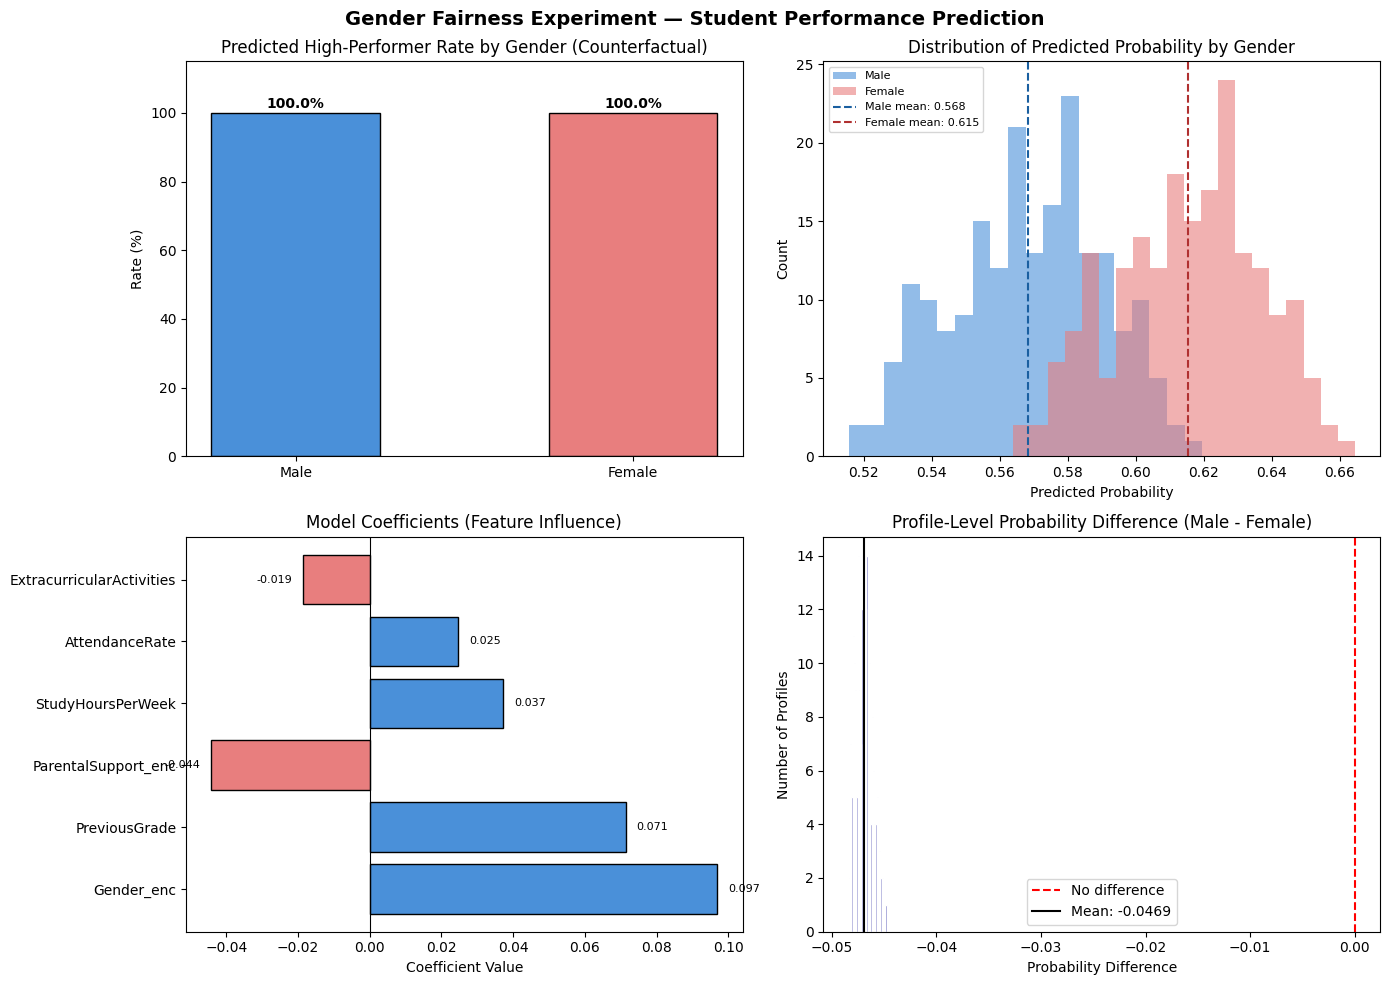

Saved: outputs/fairness_results.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Gender Fairness Experiment — Student Performance Prediction',
             fontsize=14, fontweight='bold')

# Chart 1: Pass rate bar
ax1 = axes[0, 0]
vals = [male_pass_rate, female_pass_rate]
bars1 = ax1.bar(['Male', 'Female'], vals,
                color=['#4A90D9', '#E87E7E'], edgecolor='black', width=0.5)
ax1.set_title('Predicted High-Performer Rate by Gender (Counterfactual)')
ax1.set_ylabel('Rate (%)')
ax1.set_ylim(0, 115)
for bar, val in zip(bars1, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

# Chart 2: Probability distribution
ax2 = axes[0, 1]
ax2.hist(male_cf['ProbPass'], bins=20, alpha=0.6, label='Male', color='#4A90D9')
ax2.hist(female_cf['ProbPass'], bins=20, alpha=0.6, label='Female', color='#E87E7E')
ax2.axvline(male_prob_mean,   color='#1A5FA0', linestyle='--', linewidth=1.5,
            label=f'Male mean: {male_prob_mean:.3f}')
ax2.axvline(female_prob_mean, color='#B03030', linestyle='--', linewidth=1.5,
            label=f'Female mean: {female_prob_mean:.3f}')
ax2.set_title('Distribution of Predicted Probability by Gender')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')
ax2.legend(fontsize=8)

# Chart 3: Coefficients
ax3 = axes[1, 0]
colors3 = ['#E87E7E' if c < 0 else '#4A90D9' for c in coef_df['Coefficient']]
bars3 = ax3.barh(coef_df['Feature'], coef_df['Coefficient'],
                 color=colors3, edgecolor='black')
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_title('Model Coefficients (Feature Influence)')
ax3.set_xlabel('Coefficient Value')
for bar, val in zip(bars3, coef_df['Coefficient']):
    ax3.text(val + (0.003 if val >= 0 else -0.003),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=8)

# Chart 4: Profile-level diff histogram
ax4 = axes[1, 1]
ax4.hist(pivot['Diff'], bins=30, color='#7E7EC8', edgecolor='white')
ax4.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No difference')
ax4.axvline(mean_diff, color='black', linewidth=1.5,
            label=f'Mean: {mean_diff:.4f}')
ax4.set_title('Profile-Level Probability Difference (Male - Female)')
ax4.set_xlabel('Probability Difference')
ax4.set_ylabel('Number of Profiles')
ax4.legend()

plt.tight_layout()
plt.savefig('outputs/fairness_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fairness_results.png')

## 10. Discussion & Conclusions

### What the results show

The counterfactual test used 200 unique student profiles. For each profile, only the gender label was changed while all academic variables remained identical.

**Key findings:**
- The binary High/Low Performer prediction was **not flipped** by gender in any of the 200 profiles.
- However, there is a **consistent ~4.7% difference** in predicted probability, with female students receiving slightly *higher* probabilities than males for identical profiles.
- The `Gender_enc` coefficient (0.097) is the **largest among all features**, even exceeding `PreviousGrade` — this is a fairness concern worth monitoring.

### Interpretation

The model does not strongly discriminate by gender in terms of final pass/fail decisions. However, gender having the highest coefficient means it carries more weight than academic performance factors, which is unexpected and potentially problematic.

In a real educational context, even small probability differences may influence teacher behaviour — students predicted as weaker may receive less support or lower expectations, affecting their actual outcomes over time.

### Recommendations

1. **Remove gender** from the model features — it should not outweigh academic variables.
2. Apply **fairness-aware training techniques** (e.g., reweighting, adversarial debiasing).
3. Use the model as a **support tool only**, not as a final decision system.
4. Conduct **regular audits** to monitor for emerging bias over time.

---
*All output files are saved in the `outputs/` folder.*